In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = sns.load_dataset('penguins')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [4]:
print(df.shape)
print(df.columns)
print(df.dtypes)

(344, 7)
Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object


In [5]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [30]:
df_clean = df.drop_duplicates()
print(df.duplicated().sum())

0


In [53]:
numeric_cols = df_clean.select_dtypes(exclude = 'object').columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())
df_clean.isnull().sum()

species               0
island                0
bill_length_mm        0
bill_depth_mm         0
flipper_length_mm     0
body_mass_g           0
sex                  11
dtype: int64

In [57]:
categorical_cols = df_clean.select_dtypes(include = 'object').columns
for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
df_clean.isnull().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [60]:
biscoe_df = df_clean[df_clean['island'] == 'Biscoe']
biscoe_df.shape

(168, 7)

In [66]:
df_clean[(df_clean['body_mass_g'] > df_clean['body_mass_g'].mean()) & (df_clean['sex'] == 'Male')]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,Male
14,Adelie,Torgersen,34.6,21.1,198.0,4400.0,Male
17,Adelie,Torgersen,42.5,20.7,197.0,4500.0,Male
39,Adelie,Dream,39.8,19.1,184.0,4650.0,Male
...,...,...,...,...,...,...,...
335,Gentoo,Biscoe,55.1,16.0,230.0,5850.0,Male
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,Male
337,Gentoo,Biscoe,48.8,16.2,222.0,6000.0,Male
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male


In [67]:
df_clean.sort_values(by = ['body_mass_g', 'bill_length_mm'], ascending = [True, False])

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
190,Chinstrap,Dream,46.9,16.6,192.0,2700.0,Female
58,Adelie,Biscoe,36.5,16.6,181.0,2850.0,Female
64,Adelie,Biscoe,36.4,17.1,184.0,2850.0,Female
174,Chinstrap,Dream,43.2,16.6,187.0,2900.0,Female
116,Adelie,Torgersen,38.6,17.0,188.0,2900.0,Female
...,...,...,...,...,...,...,...
299,Gentoo,Biscoe,45.2,16.4,223.0,5950.0,Male
297,Gentoo,Biscoe,51.1,16.3,220.0,6000.0,Male
337,Gentoo,Biscoe,48.8,16.2,222.0,6000.0,Male
253,Gentoo,Biscoe,59.6,17.0,230.0,6050.0,Male


In [71]:
df_clean.groupby('species')['body_mass_g'].mean().sort_values(ascending = False)

species
Gentoo       5067.741935
Chinstrap    3733.088235
Adelie       3702.960526
Name: body_mass_g, dtype: float64

In [72]:
df_clean.groupby(['species', 'sex'])['body_mass_g'].mean()

species    sex   
Adelie     Female    3368.835616
           Male      4011.708861
Chinstrap  Female    3527.205882
           Male      3938.970588
Gentoo     Female    4679.741379
           Male      5408.712121
Name: body_mass_g, dtype: float64

In [74]:
df_clean.groupby('island')['island'].count()

island
Biscoe       168
Dream        124
Torgersen     52
Name: island, dtype: int64

In [80]:
df_clean['bill_ratio'] = df_clean['bill_length_mm']/df_clean['bill_depth_mm']
df_clean['bill_ratio'].describe()

count    344.000000
mean       2.605438
std        0.495930
min        1.639810
25%        2.161882
50%        2.571484
75%        3.097572
max        3.612676
Name: bill_ratio, dtype: float64

In [83]:
df_clean.groupby('species')['bill_ratio'].mean().sort_values(ascending = False).head(1)

species
Gentoo    3.170703
Name: bill_ratio, dtype: float64

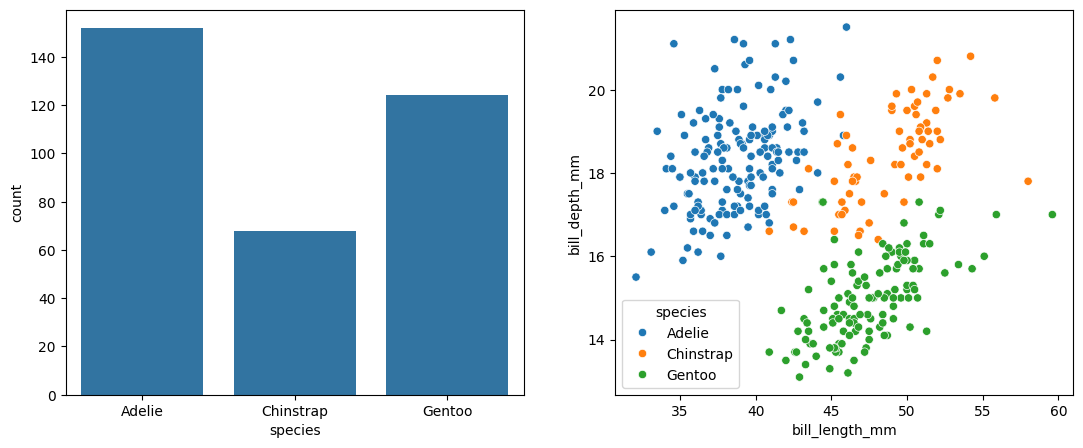

In [90]:
plt.figure(figsize = (13,5))

plt.subplot(1,2,1)
sns.countplot(x = 'species', data = df_clean)

plt.subplot(1,2,2)
sns.scatterplot(x = 'bill_length_mm', y = 'bill_depth_mm', hue = 'species', data = df_clean)
plt.show()

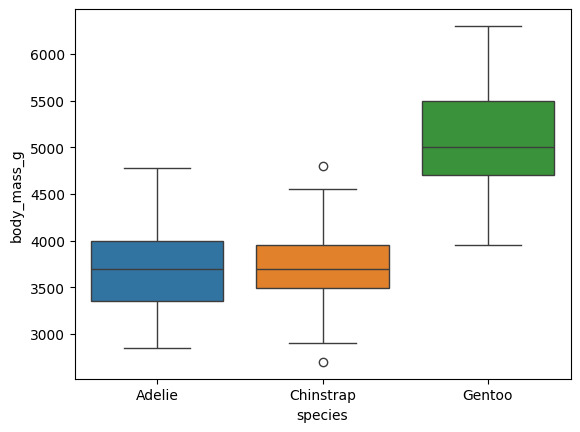

In [94]:
sns.boxplot(y = 'body_mass_g', x = 'species', hue = 'species', data = df_clean)
plt.show()

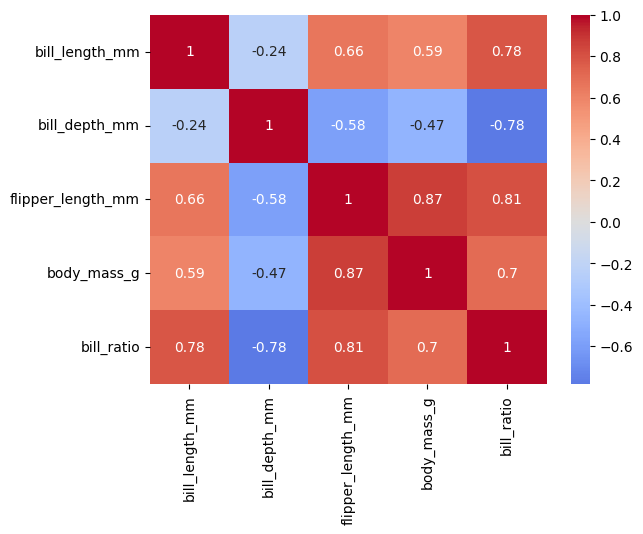

In [99]:
corr_matrix = df_clean.select_dtypes(include = 'number').corr()
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', center = 0)
plt.show()

In [32]:
y = df_clean['species']
X = df_clean.drop(columns = 'species')

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [36]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()
numeric_transformer = Pipeline(steps=[
("imputer", SimpleImputer(strategy="median")),
("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
("imputer", SimpleImputer(strategy="most_frequent")),
("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocess = ColumnTransformer (
transformers=[
("'num", numeric_transformer, numeric_features),
("cat", categorical_transformer, categorical_features),
])


In [37]:
knn_model = Pipeline( steps = [
    ('preprocess', preprocess),
    ('model', KNeighborsClassifier(n_neighbors = 5))
])

In [39]:
logreg_model = Pipeline(steps = [
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter = 2000))
])

In [45]:
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.9855072463768116
